# Wind-Field Asymmetry: IKE and Radii Decomposition (Geographic / Shear-Relative / Motion-Relative)

Six figures examining hurricane-force+ wind-field asymmetry:
1. Total IKE + R34 by geographic quadrant (polar bar)
2. IKE-band + radii decomposition by geographic quadrant (stacked polar bar)
3. Same decomposition, rotated into the SHIPS deep-layer shear vector's frame
4. Same decomposition, rotated into the storm's own motion heading
5-6. Intensity (Vmax) distribution of the timesteps contributing to figures 1-2 (or 3),
   with Saffir-Simpson context bands

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["SHIPS_PATH"] = "/data/jacob.carstens/SHIPS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch

from ike_climatology import config
from ike_climatology.wind_asymmetry import (
    load_master_dataframe_quadrant,
    compute_basin_asymmetry_results,
    compute_global_scale_limits,
)


## Data extraction

`load_master_dataframe_quadrant` handles per-basin IBTrACS + SHIPS loading, genesis-
basin-code filtering, and the quadrant IKE/radii decomposition
(`calculate_quadrant_ike_metrics`) -- a genuinely different computation from
`calculate_storm_metrics` used elsewhere in this repo, since it needs to keep all four
quadrants separate rather than collapsing each IKE band to one scalar per timestep, and
merges in SHIPS shear direction/magnitude, which no other figure in this repo uses.

`INTENSITY_THRESHOLD_KT`: 64 = hurricane force, 96 = major (Cat 3+). Only timesteps at or
above this Vmax are retained anywhere in this notebook.

In [3]:
INTENSITY_THRESHOLD_KT = 64

master_df = load_master_dataframe_quadrant(
    basins=config.BASINS_TO_ANALYZE,
    ibtracs_file_map=config.IBTRACS_FILE_MAP,
    ships_file_map=config.SHIPS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    ships_base_path=config.SHIPS_BASE_PATH,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    intensity_threshold_kt=INTENSITY_THRESHOLD_KT,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH/SHIPS_PATH.")

basin_results, sample_size_records = compute_basin_asymmetry_results(master_df)
global_max_ike, global_max_r34 = compute_global_scale_limits(basin_results)
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)


--- Starting Data Loading ---
    - Loading IBTrACS & SHIPS Data for North Atlantic...
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS & SHIPS Data for East Pacific...
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS & SHIPS Data for West Pacific...
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS & SHIPS Data for North Indian...
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS & SHIPS Data for South Indian...
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS & SHIPS Data for South Pacific...
        - Filtered out 12 crossover/external storms based on official genesis basin label.

--- Master dataset compiled for Hurricane Phase timesteps (12690 valid base timesteps) ---


## Shared plot helper

Two-line panel title: `"a) Basin name"` on top, `"(n = X storms)"` below.

In [4]:
def _build_panel_title(basin_full_name, n_storms, panel_label=None):
    prefix = f"{panel_label}) " if panel_label else ""
    return f"{prefix}{basin_full_name}\n(n = {n_storms:,} storms)"


def _add_vector_arrow(ax, y_max):
    ax.annotate("", xy=(0, y_max), xytext=(0, 0),
                arrowprops=dict(facecolor="black", shrink=0.05, width=2, headwidth=10, alpha=0.3),
                zorder=100, ha="center", va="center", fontsize=10, fontweight="bold", alpha=0.6)


## Figure 1: Geographic Total IKE + R34

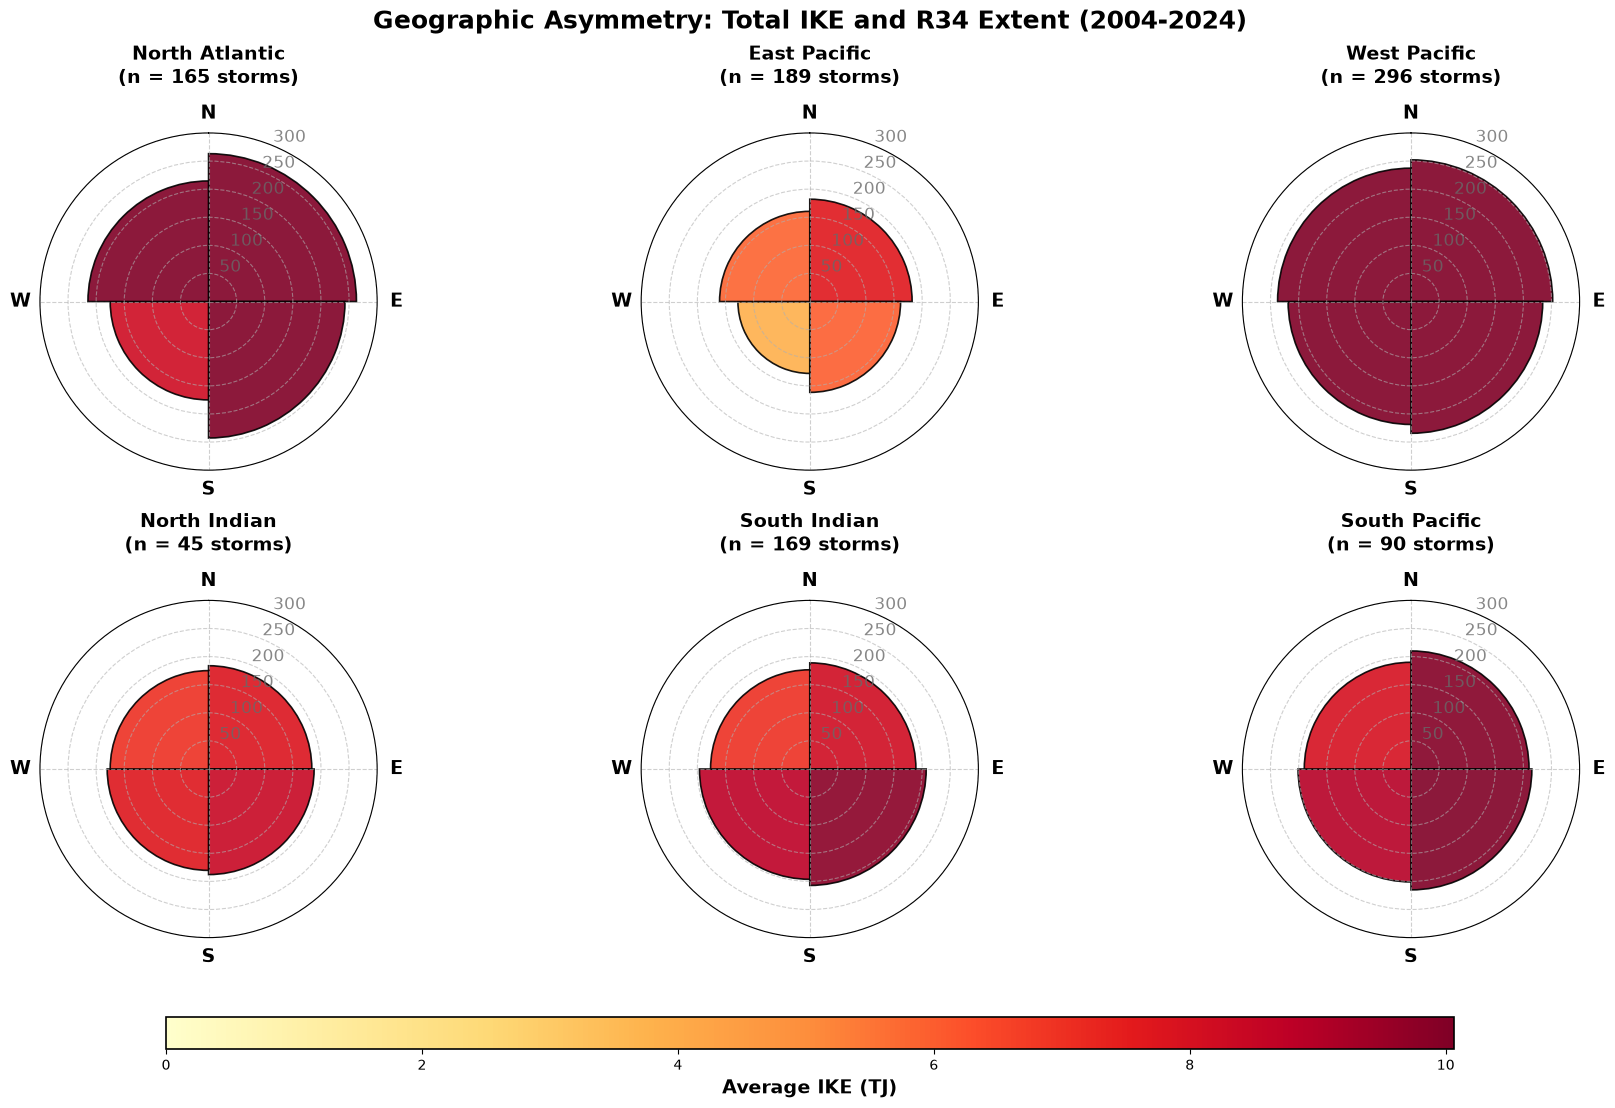

In [5]:
def plot_geographic_total_ike():
    fig, axes = plt.subplots(2, 3, subplot_kw={"projection": "polar"}, figsize=(18, 11), constrained_layout=True)
    axes = axes.flatten()

    angles = np.array([np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4])
    width = 1.5708
    y_tick_max = int(np.ceil(global_max_r34 / 50.0)) * 50
    y_ticks = np.arange(50, y_tick_max + 1, 50)
    cmap = plt.get_cmap("YlOrRd")
    norm = mcolors.Normalize(vmin=0, vmax=global_max_ike)

    for i, basin in enumerate(config.BASINS_TO_ANALYZE):
        ax = axes[i]
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        abbrev = config.IBTRACS_BASIN_CODES[basin]
        if abbrev not in basin_results:
            ax.set_title(f"{basin}\n(No Data)", fontsize=14, fontweight="bold", pad=15)
            ax.set_xticks([]); ax.set_yticks([]); continue

        data = basin_results[abbrev]
        r34 = np.nan_to_num(data["r34_geo_avg"])
        total_ike = np.nan_to_num(data["total_geo_avg_ike"])
        colors = [cmap(norm(val)) for val in total_ike]

        ax.bar(angles, r34, width=width, bottom=0, color=colors, edgecolor="black", alpha=0.9, linewidth=1.2)
        ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
        ax.set_xticklabels(["N", "E", "S", "W"], fontsize=14, fontweight="bold")
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([str(t) for t in y_ticks], color="dimgrey", size=12, alpha=0.8)
        ax.set_ylim(0, y_tick_max)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.set_title(_build_panel_title(basin, data["n_storms_geo"]),
                     fontsize=14, fontweight="bold", pad=15)
        
    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.04, pad=0.06, aspect=40)
    cbar.set_label("Average IKE (TJ)", fontsize=14, fontweight="bold")
    cbar.outline.set_linewidth(1.2)

    fig.suptitle(f"Geographic Asymmetry: Total IKE and R34 Extent ({config.START_YEAR}-{config.END_YEAR})",
                 fontsize=18, fontweight="bold")
    plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "totalike_basin.png"), dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


plot_geographic_total_ike()


## Figure 2: Geographic Radii Decomposition

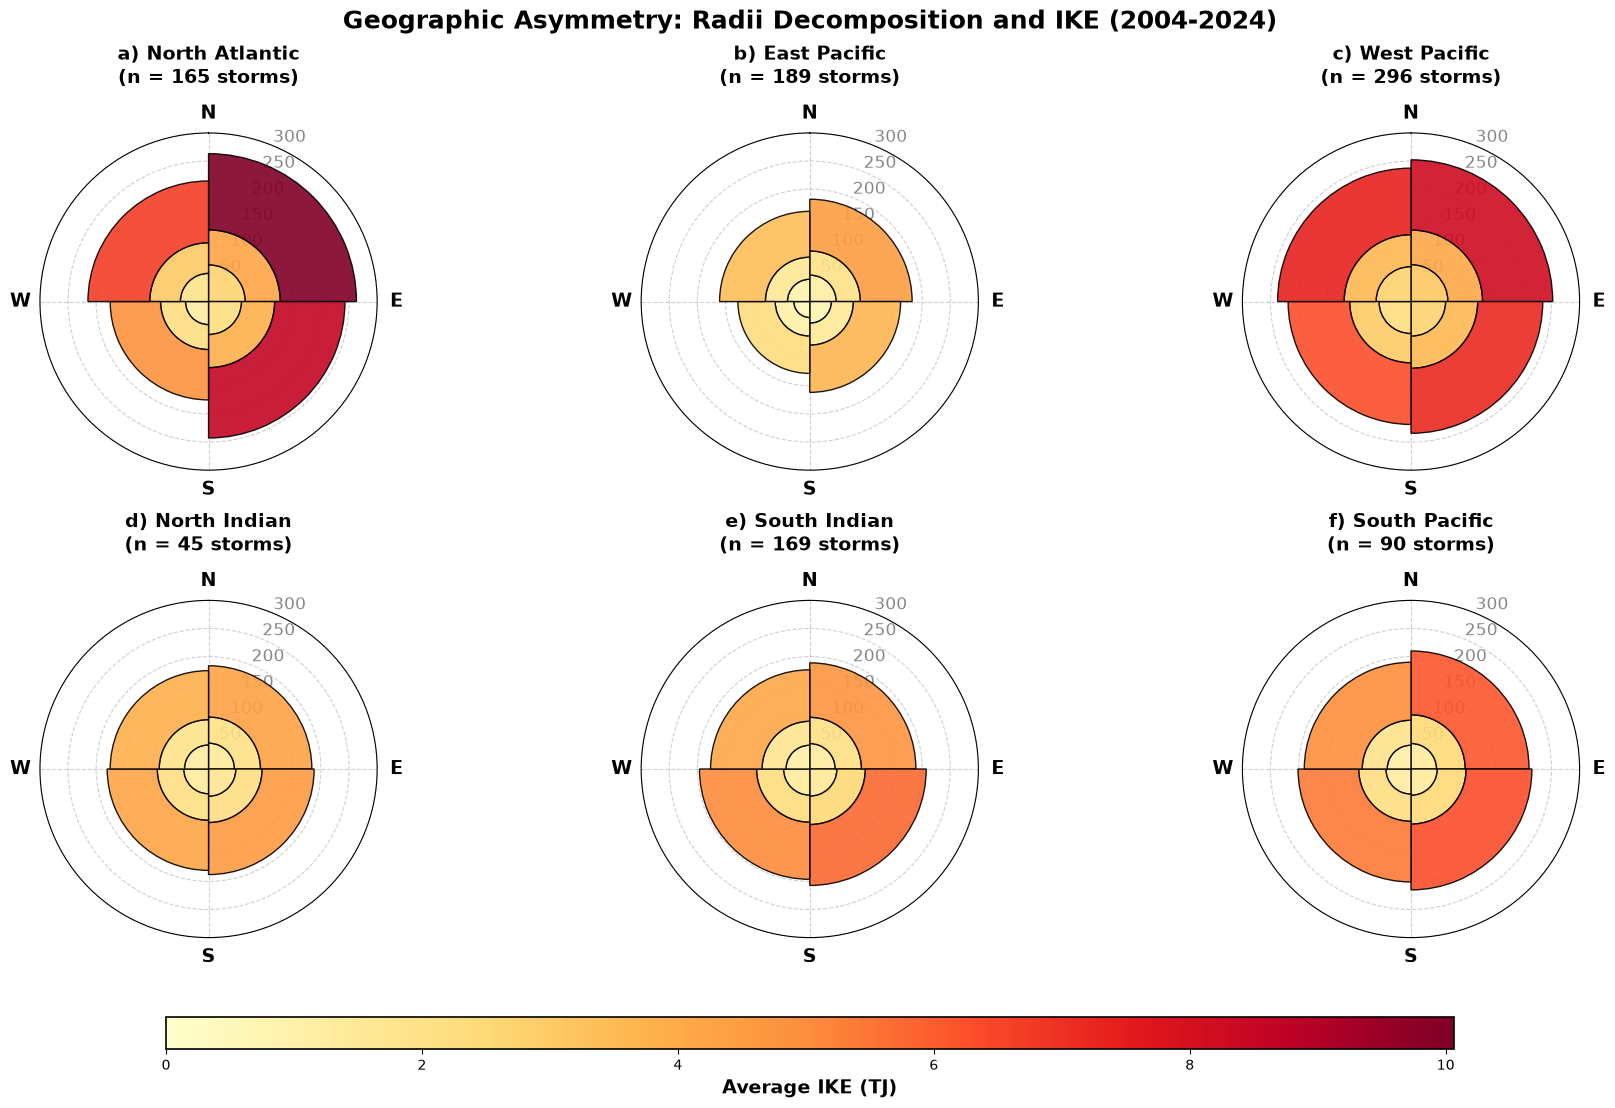

In [6]:
def _plot_decomposition(prefix, xtick_labels, title, filename, use_arrow=False):
    fig, axes = plt.subplots(2, 3, subplot_kw={"projection": "polar"}, figsize=(18, 11), constrained_layout=True)
    axes = axes.flatten()

    angles = np.array([np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4])
    width = 1.5708
    y_tick_max = int(np.ceil(global_max_r34 / 50.0)) * 50
    y_ticks = np.arange(50, y_tick_max + 1, 50)
    cmap = plt.get_cmap("YlOrRd")
    norm = mcolors.Normalize(vmin=0, vmax=global_max_ike)

    for i, basin in enumerate(config.BASINS_TO_ANALYZE):
        ax = axes[i]
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        if use_arrow:
            _add_vector_arrow(ax, y_tick_max)

        abbrev = config.IBTRACS_BASIN_CODES[basin]
        missing = abbrev not in basin_results
        if not missing and use_arrow:
            missing = np.isnan(basin_results[abbrev][f"ike1826_{prefix}_avg"][0])

        if missing:
            ax.set_title(f"{basin}\n(No Data)", fontsize=14, fontweight="bold", pad=15)
            ax.set_xticks([]); ax.set_yticks([]); continue

        data = basin_results[abbrev]
        r64 = np.nan_to_num(data[f"r64_{prefix}_avg"])
        r50 = np.nan_to_num(data[f"r50_{prefix}_avg"])
        r34 = np.nan_to_num(data[f"r34_{prefix}_avg"])

        len_hur = r64
        len_2633 = np.maximum(0, r50 - r64)
        len_1826 = np.maximum(0, r34 - r50)

        c_hur = [cmap(norm(val)) for val in np.nan_to_num(data[f"ikehur_{prefix}_avg"])]
        c_2633 = [cmap(norm(val)) for val in np.nan_to_num(data[f"ike2633_{prefix}_avg"])]
        c_1826 = [cmap(norm(val)) for val in np.nan_to_num(data[f"ike1826_{prefix}_avg"])]

        ax.bar(angles, len_hur, width=width, bottom=0, color=c_hur, edgecolor="black", alpha=0.9, linewidth=1, zorder=2)
        ax.bar(angles, len_2633, width=width, bottom=r64, color=c_2633, edgecolor="black", alpha=0.9, linewidth=1, zorder=2)
        ax.bar(angles, len_1826, width=width, bottom=r50, color=c_1826, edgecolor="black", alpha=0.9, linewidth=1, zorder=2)

        ax.set_xticks(angles if use_arrow else [0, np.pi/2, np.pi, 3*np.pi/2])
        ax.set_xticklabels(xtick_labels, fontsize=14, fontweight="bold")
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([str(t) for t in y_ticks], color="dimgrey", size=12, alpha=0.8)
        ax.set_ylim(0, y_tick_max)
        ax.grid(True, linestyle="--", alpha=0.6, zorder=0)
        ax.set_title(_build_panel_title(basin, data[f"n_storms_{prefix}"], panel_label=chr(97 + i)),
                     fontsize=14, fontweight="bold", pad=15)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.04, pad=0.06, aspect=40)
    cbar.set_label("Average IKE (TJ)", fontsize=14, fontweight="bold")
    cbar.outline.set_linewidth(1.2)

    fig.suptitle(f"{title} ({config.START_YEAR}-{config.END_YEAR})", fontsize=18, fontweight="bold")
    plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, filename), dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


_plot_decomposition(
    prefix="geo", xtick_labels=["N", "E", "S", "W"],
    title="Geographic Asymmetry: Radii Decomposition and IKE",
    filename="georelative_basindecomp.png", use_arrow=False,
)


## Figure 3: Shear-Relative Radii Decomposition

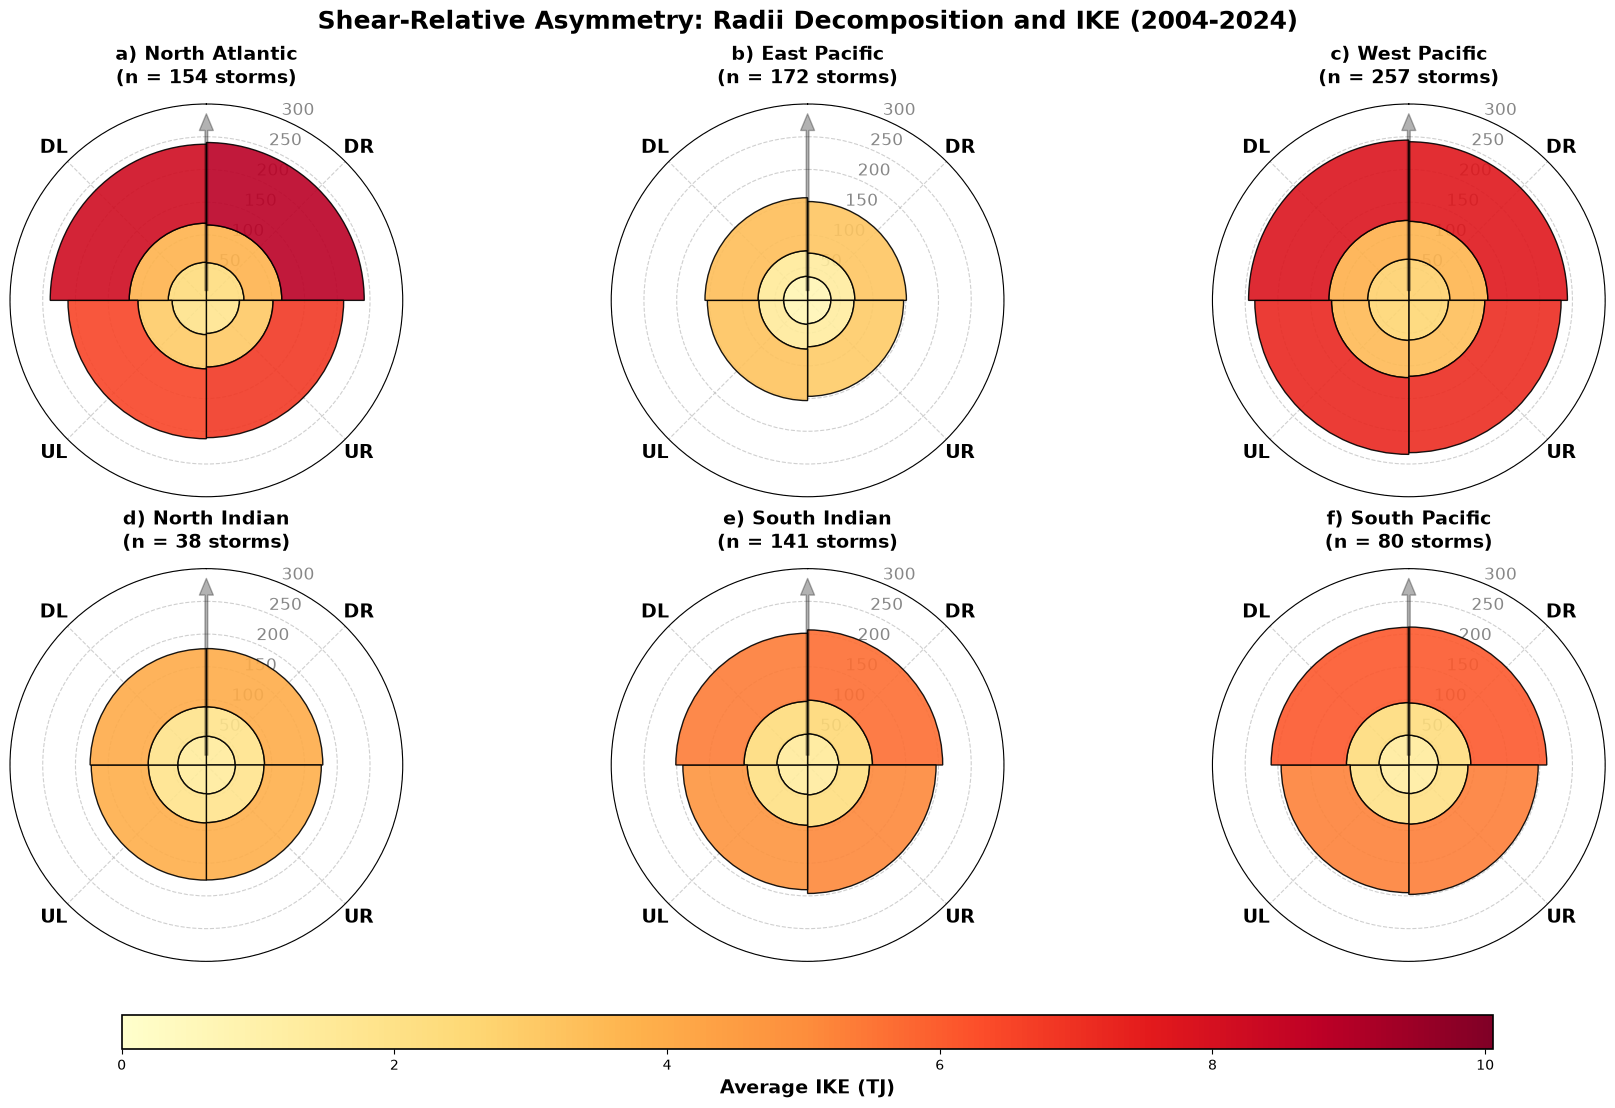

In [7]:
_plot_decomposition(
    prefix="sr", xtick_labels=["DR", "UR", "UL", "DL"],
    title="Shear-Relative Asymmetry: Radii Decomposition and IKE",
    filename="shearrelative_basindecomp.png", use_arrow=True,
)


## Figure 4: Motion-Relative Radii Decomposition

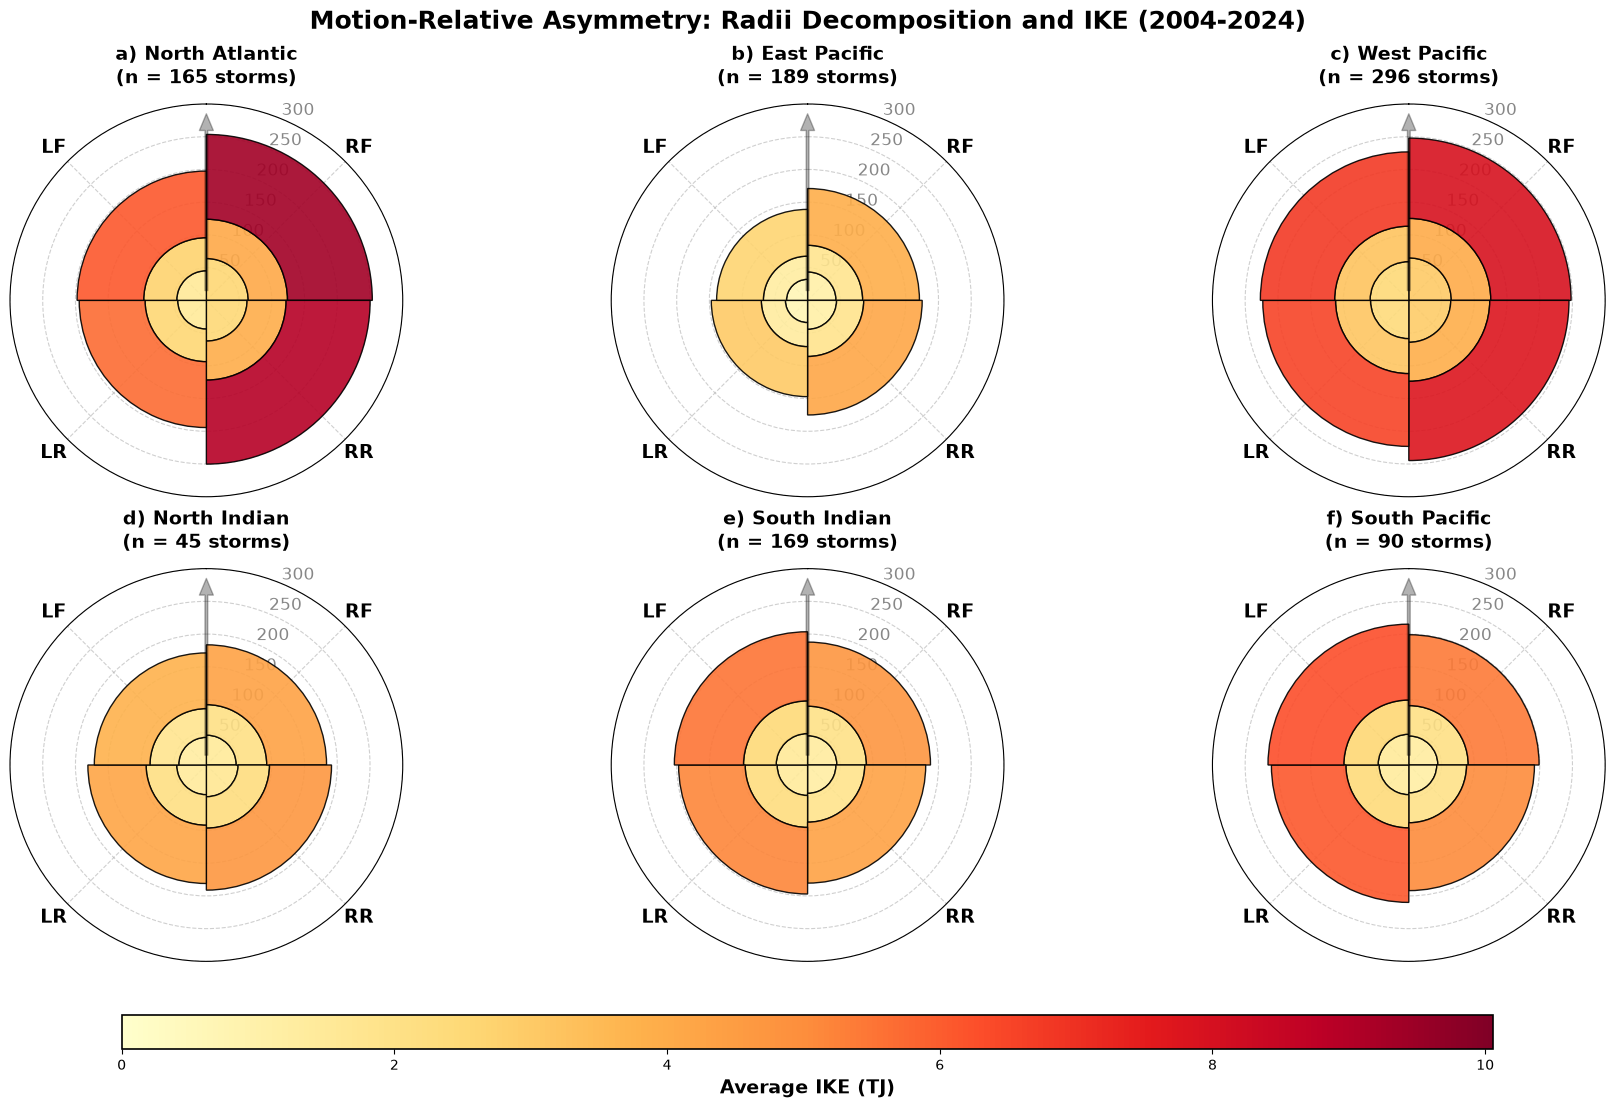

In [8]:
_plot_decomposition(
    prefix="mr", xtick_labels=["RF", "RR", "LR", "LF"],
    title="Motion-Relative Asymmetry: Radii Decomposition and IKE",
    filename="motionrelative_basindecomp.png", use_arrow=True,
)


## Sample sizes for figure captions

Writes a CSV and prints caption-ready timestep/storm-count strings for figures 1-2
(geographic), 3 (shear-relative), and 4 (motion-relative).

In [9]:
sample_size_df = pd.DataFrame(sample_size_records)
csv_path = os.path.join(config.BASE_OUTPUT_DIR, "sample_sizes_by_basin.csv")
sample_size_df.to_csv(csv_path, index=False)
print(f"Full table saved: {csv_path}\n")

print(f"{'Basin':<18} {'GEO storms':>12} {'GEO timesteps':>15} "
      f"{'SR storms':>12} {'SR timesteps':>15} "
      f"{'MR storms':>12} {'MR timesteps':>15}")
print("-" * 100)
for rec in sample_size_records:
    print(f"{rec['basin']:<18} {rec['n_storms_geo']:>12,} {rec['n_timesteps_geo']:>15,} "
          f"{rec['n_storms_sr']:>12,} {rec['n_timesteps_sr']:>15,} "
          f"{rec['n_storms_mr']:>12,} {rec['n_timesteps_mr']:>15,}")
print("-" * 100)

print("\nCaption-ready timestep listings:\n")
geo_caption = "; ".join(f"{r['abbrev']}: {r['n_timesteps_geo']:,} timesteps from {r['n_storms_geo']:,} storms"
                        for r in sample_size_records)
print("GEOGRAPHIC plots (Figs 1 & 2):\n  " + geo_caption + ".")

sr_caption = "; ".join(f"{r['abbrev']}: {r['n_timesteps_sr']:,} timesteps from {r['n_storms_sr']:,} storms"
                       for r in sample_size_records)
print("\nSHEAR-RELATIVE plot (Fig 3):\n  " + sr_caption + ".")

mr_caption = "; ".join(f"{r['abbrev']}: {r['n_timesteps_mr']:,} timesteps from {r['n_storms_mr']:,} storms"
                       for r in sample_size_records)
print("\nMOTION-RELATIVE plot (Fig 4):\n  " + mr_caption + ".")


Full table saved: /home/sydney.e.walters/IBTrACS_Manuscript_Figures/sample_sizes_by_basin.csv

Basin                GEO storms   GEO timesteps    SR storms    SR timesteps    MR storms    MR timesteps
----------------------------------------------------------------------------------------------------
East Pacific                189           2,340          172           2,045          189           2,340
North Atlantic              165           2,355          154           2,204          165           2,355
North Indian                 45             406           38             332           45             406
South Indian                169           2,033          141           1,664          169           2,033
South Pacific                90           1,120           80           1,037           90           1,120
West Pacific                296           4,436          257           3,905          296           4,436
--------------------------------------------------------------

## Figures 5-6: Intensity (Vmax) distribution diagnostics

Histogram of the Vmax values behind the geographic/motion-relative subset (Fig 5) and
shear-relative subset (Fig 6), with Saffir-Simpson context bands. `INT_DIST_MAJOR_ONLY`
restricts to majors (Cat 3+); `INT_DIST_WEIGHT` switches from raw timestep counts to
IKE-weighted histograms (`"total"`, or `"hur"` to isolate whether the >=64-kt IKE signal
is carried by weak Cat 1s or genuinely strong systems).

In [10]:
INT_DIST_MAJOR_ONLY = False   # True -> restrict histograms to majors (>=96 kt)
INT_DIST_WEIGHT = None        # None=timestep counts | "total"=weight by total IKE | "hur"=weight by 64-kt-tier IKE
MAJOR_THRESHOLD_KT = 96       # Cat 3+
BIN_WIDTH_KT = 5              # best-track vmax is reported in 5-kt steps

SS_LOWERS = [64, 83, 96, 113, 137]
SS_UPPERS = [83, 96, 113, 137, 500]
SS_NAMES = ["1", "2", "3", "4", "5"]
SS_BAND_COLORS = ["#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"]


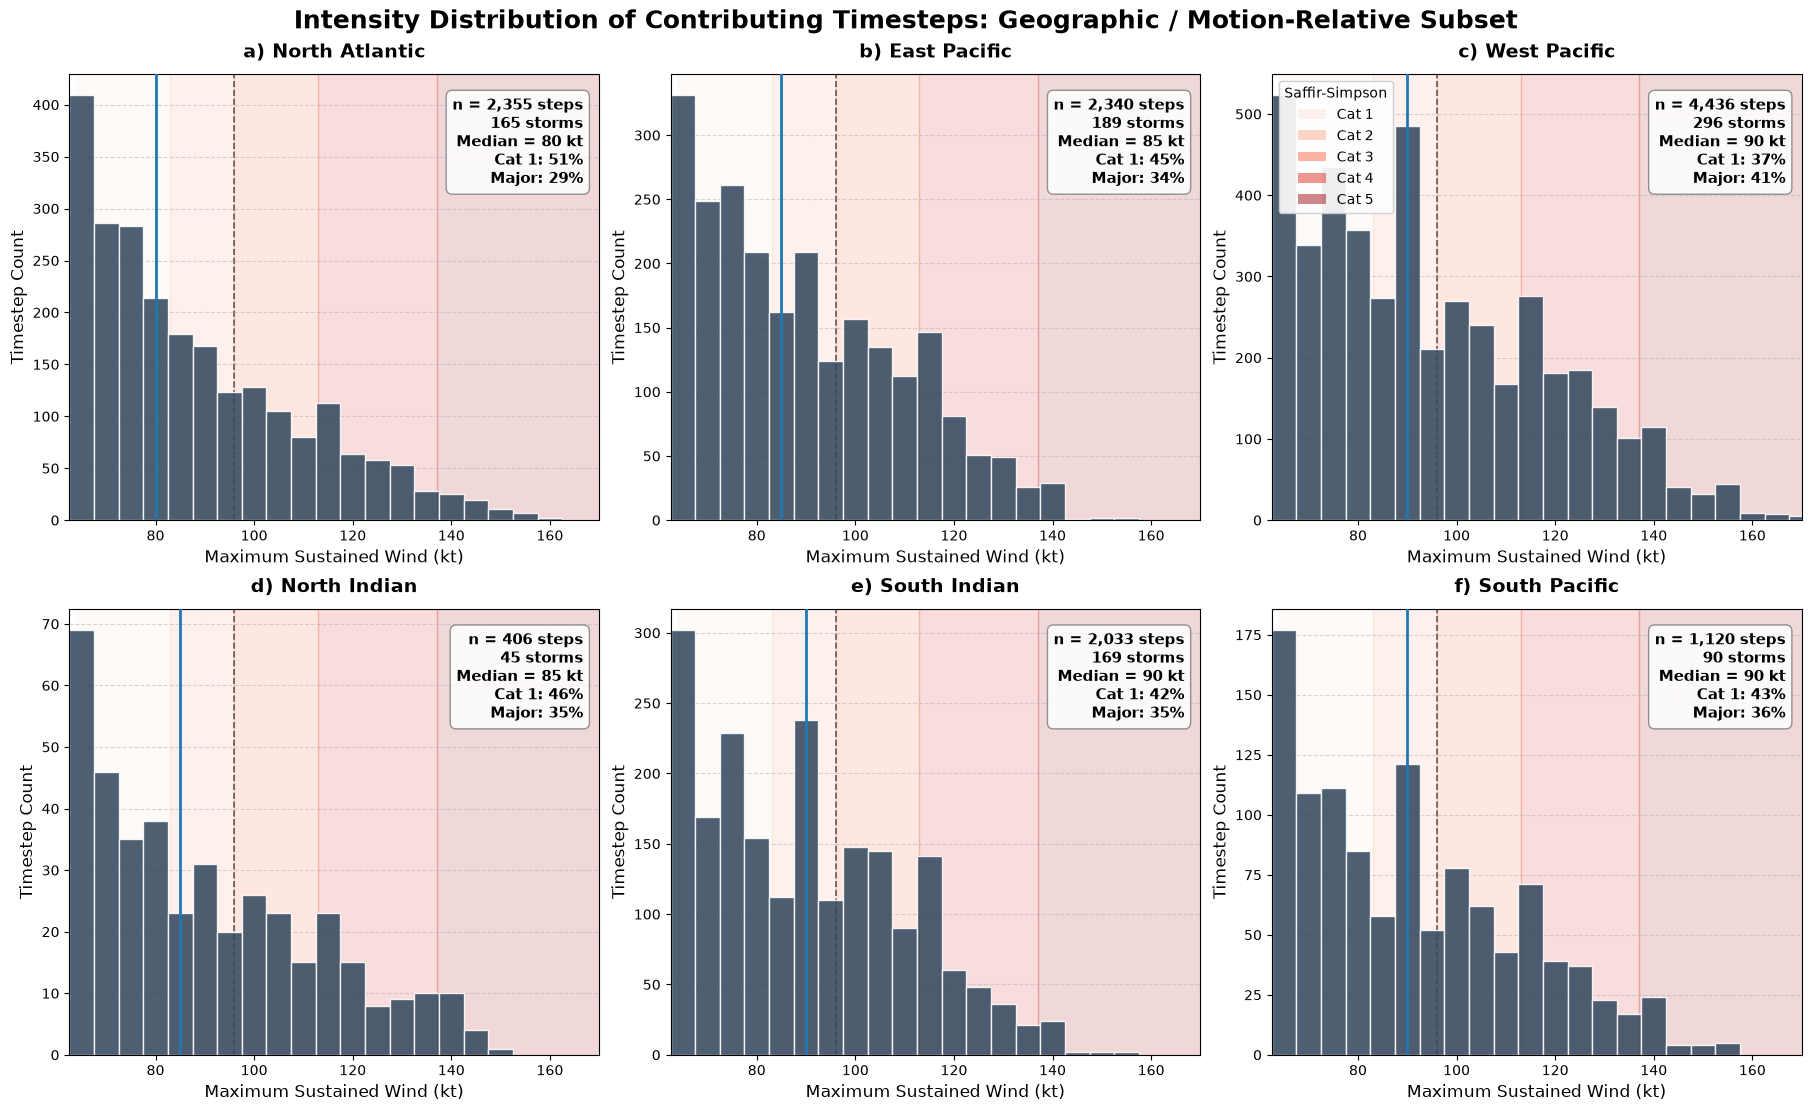

  > Saved intensity_dist_geomotion.png


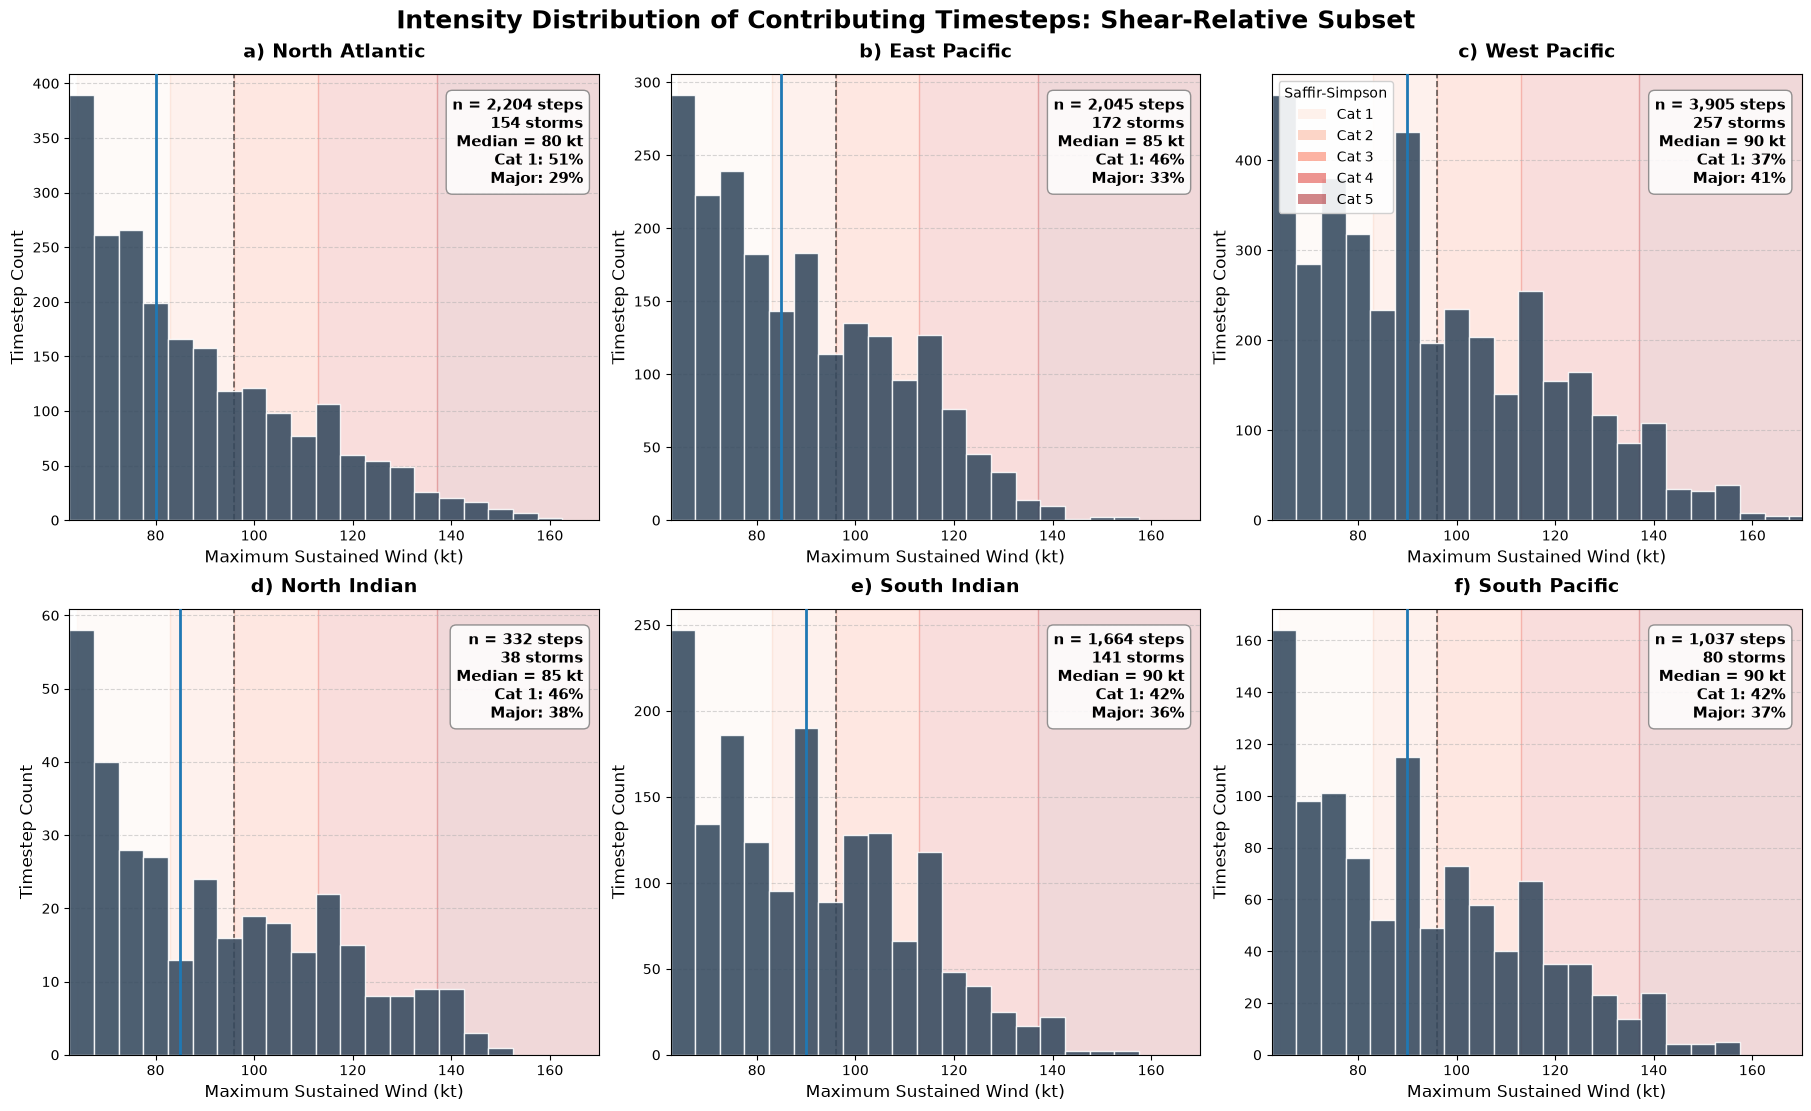

  > Saved intensity_dist_shear.png


In [11]:
def _frame_subset(basin_group, frame):
    if frame == "geo":
        return basin_group.copy()
    if frame == "sr":
        s = basin_group.dropna(subset=["s_dir"]).copy()
        return s[s["ike1826_sr_quad"].apply(lambda x: isinstance(x, list) and len(x) == 4)]
    if frame == "mr":
        m = basin_group.dropna(subset=["m_dir"]).copy()
        return m[m["ike1826_mr_quad"].apply(lambda x: isinstance(x, list) and len(x) == 4)]
    raise ValueError(f"Unknown frame: {frame}")


def _weighted_median(v, w):
    if len(v) == 0 or np.nansum(w) <= 0:
        return np.nan
    order = np.argsort(v)
    v, w = np.asarray(v)[order], np.asarray(w)[order]
    cw = np.cumsum(w)
    return v[np.searchsorted(cw, cw[-1] / 2.0)]


def plot_intensity_distribution(frame="geo", major_only=False, weight=None, fname=None, title=None):
    groups = {basin: g for basin, g in master_df.groupby("basin")}

    hur_col = {"geo": "ikehur_geo_quad", "sr": "ikehur_sr_quad", "mr": "ikehur_mr_quad"}[frame]
    bins = np.arange(62.5, 177.5, BIN_WIDTH_KT)

    fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
    axes = axes.flatten()

    for i, basin in enumerate(config.BASINS_TO_ANALYZE):
        ax = axes[i]

        for lo, hi, c in zip(SS_LOWERS, SS_UPPERS, SS_BAND_COLORS):
            ax.axvspan(lo, hi, color=c, alpha=0.16, zorder=0)
        ax.axvline(MAJOR_THRESHOLD_KT, color="black", ls="--", lw=1.2, alpha=0.6, zorder=1)

        if basin not in groups:
            ax.set_title(f"{basin}\n(No Data)", fontsize=14, fontweight="bold", pad=12)
            ax.set_xticks([]); ax.set_yticks([]); continue

        sub = _frame_subset(groups[basin], frame)

        d = pd.DataFrame({"vmax": sub["vmax_kts"].astype(float).values})
        if weight == "total":
            d["w"] = sub["total_ike_tj"].astype(float).values
        elif weight == "hur":
            d["w"] = sub[hur_col].apply(lambda x: np.nansum(x) if isinstance(x, list) else np.nan).values
        else:
            d["w"] = 1.0
        d = d.dropna(subset=["vmax"])
        if major_only:
            d = d[d["vmax"] >= MAJOR_THRESHOLD_KT]

        v, w = d["vmax"].values, d["w"].values
        n_ts = len(v)
        n_storms = sub["storm_id"].nunique()

        ax.hist(v, bins=bins, weights=w, color="#34495e", edgecolor="white", alpha=0.88, zorder=2)

        wsum = np.nansum(w)
        if wsum > 0:
            pct_cat1 = 100 * np.nansum(w[(v >= 64) & (v < 83)]) / wsum
            pct_major = 100 * np.nansum(w[v >= 96]) / wsum
            med = _weighted_median(v, w)
            ax.axvline(med, color="#1f78b4", lw=2, zorder=3)
            txt = (f"n = {n_ts:,} steps\n{n_storms:,} storms\n"
                   f"Median = {med:.0f} kt\nCat 1: {pct_cat1:.0f}%\nMajor: {pct_major:.0f}%")
        else:
            txt = f"n = {n_ts:,} steps\n{n_storms:,} storms"

        ax.text(0.97, 0.95, txt, transform=ax.transAxes, ha="right", va="top",
                fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=0.85))

        ax.set_title(f"{chr(97 + i)}) {basin}", fontsize=14, fontweight="bold", pad=12)
        ax.set_xlim(62.5, 170)
        ax.set_xlabel("Maximum Sustained Wind (kt)", fontsize=12)
        ax.set_ylabel("IKE (TJ)" if weight else "Timestep Count", fontsize=12)
        ax.grid(True, axis="y", ls="--", alpha=0.5)

    legend_patches = [Patch(fc=c, alpha=0.5, label=f"Cat {n}") for n, c in zip(SS_NAMES, SS_BAND_COLORS)]
    axes[2].legend(handles=legend_patches, loc="upper left", fontsize=10, framealpha=0.9, title="Saffir-Simpson")

    suffix = " (majors only)" if major_only else ""
    fig.suptitle((title or f"Intensity Distribution: {frame.upper()} subset") + suffix,
                 fontsize=18, fontweight="bold")
    fname = fname or f"intensity_dist_{frame}{'_major' if major_only else ''}.png"
    plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, fname), dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  > Saved {fname}")


plot_intensity_distribution(
    frame="geo", major_only=INT_DIST_MAJOR_ONLY, weight=INT_DIST_WEIGHT,
    fname="intensity_dist_geomotion.png",
    title="Intensity Distribution of Contributing Timesteps: Geographic / Motion-Relative Subset",
)

plot_intensity_distribution(
    frame="sr", major_only=INT_DIST_MAJOR_ONLY, weight=INT_DIST_WEIGHT,
    fname="intensity_dist_shear.png",
    title="Intensity Distribution of Contributing Timesteps: Shear-Relative Subset",
)
